In [13]:
#1
%matplotlib inline 
%load_ext autoreload
%autoreload 2

import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp

torch.manual_seed(42)
torch.set_default_dtype(torch.float64)


T = 60e-6           
B = 2e6             
Fs = 5 * B          
N = int(np.round(T * Fs)) 

N_fft = 2**14


t_np = np.linspace(0, T, N, endpoint=False)
t = torch.tensor(t_np, dtype=torch.float64)

t_norm = t / torch.max(t)

b_slope = B/T
psi = 2 * np.pi * (b_slope/2) * t**2
a = 1
s_base = a * torch.complex(torch.cos(psi), torch.sin(psi))

 
# Nulls real frequencies for N_FFT = 2**14
null_targets = [0.4e6]
nulls = []

for f_val in null_targets:
    df = Fs / N_fft
    bin_idx = int(np.round(f_val / df))
    nulls.append(bin_idx * df)

null_freqs = nulls
print(f"Targets defined at: {[f/1e6 for f in null_freqs]} MHz")


# Steering Matrix
steering_vectors = []
for f in null_freqs:
    w = 2 * np.pi * f
    vec = torch.complex(torch.cos(w * t), -torch.sin(w * t))
    steering_vectors.append(vec)

steering_matrix = torch.stack(steering_vectors)


z = torch.tensor(hlp.build_z(a,psi,t,null_freqs))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Targets defined at: [0.3997802734375] MHz


In [3]:
from version1 import getphi
phi_start =  torch.tensor(getphi(null_freqs), dtype=torch.float64, requires_grad=True)
phi_start = phi_start.squeeze()

s_lin = s_base * torch.exp(1j * phi_start)


Null at around 0.40 MHz: Depth = -39.80 dB


In [ ]:
# יצירת וקטור רנדומלי בטווח [15 ,15-]
#phi_start = (30 * torch.rand(600, dtype=torch.float64) - 15).detach().requires_grad_(True)
phi_start = torch.zeros(N, dtype=torch.float64, requires_grad=True)
print("initial_phi_shape:", phi_start.shape)


initial_phi_shape: torch.Size([600])


In [ ]:
def calculate_mf_pslr_islr_torch(signal, db=False):
    
    matched_filter = torch.conj(torch.flip(signal, dims=[0]))
    
    conv_len = signal.shape[0] + matched_filter.shape[0] - 1
    mf = torch.fft.ifft(torch.fft.fft(signal, n=conv_len) * torch.fft.fft(matched_filter, n=conv_len))
    

    mf_abs = torch.abs(mf)
    mf_db = 20 * torch.log10(mf_abs + 1e-20)
    
    # PSLR Calculation
    center_idx = len(mf) // 2
    main_lobe_width_seconds = 2 / B
    margin_samples = int((main_lobe_width_seconds / 2) * Fs)
    left_side = mf_db[:center_idx - margin_samples]
    right_side = mf_db[center_idx + margin_samples:]

    mainlobe_region =mf_db[center_idx - margin_samples:center_idx + margin_samples]
    sidelobe_region = torch.cat((left_side, right_side))

    max_sidelobe_db = torch.max(sidelobe_region)
    max_mainlobe_db = torch.max(mainlobe_region)

    # ISLR calculation 
    n_main = torch.arange(len(mf_db[center_idx - margin_samples : center_idx + margin_samples]), dtype=mf_abs.dtype, device=mf_abs.device)
    n_left = torch.arange(len(left_side), dtype=mf_abs.dtype, device=mf_abs.device)
    n_right = torch.arange(len(right_side), dtype=mf_abs.dtype, device=mf_abs.device)
    
    main_lobe_linear = mf_abs[center_idx - margin_samples : center_idx + margin_samples]
    left_side_linear = mf_abs[:center_idx - margin_samples]
    right_side_linear = mf_abs[center_idx + margin_samples:] 

    main_lobe_energy = torch.trapezoid(main_lobe_linear ** 2, x=n_main)
    sidelobe_energy = torch.trapezoid(left_side_linear ** 2, x=n_left) + torch.trapezoid(right_side_linear ** 2, x=n_right)
    
    if db:
        # PSLR כערך שלילי (Sidelobe vs Mainlobe)
        pslr = max_sidelobe_db - max_mainlobe_db
        islr = 10 * torch.log10(sidelobe_energy / (main_lobe_energy + 1e-40))
    else:
        # בחישוב ליניארי - עבודה ישירה עם הערכים הליניאריים
        max_sidelobe_linear = torch.max(torch.cat((left_side_linear, right_side_linear)))
        max_mainlobe_linear = torch.max(main_lobe_linear)
        
        pslr = max_sidelobe_linear / (max_mainlobe_linear + 1e-40)
        pslr = pslr**2
        islr = sidelobe_energy / (main_lobe_energy + 1e-40)
        


    return mf_db, pslr, islr

    #TODO change len()/2 to max or argmax 

In [15]:
# 2
import copy 

phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

learning_rate =  0.01
iterations = 5000 

beta_smooth = 1
beta_norm = 1

beta_pslr = 1
beta_islr = 1

beta_div1 = 1
beta_div2 = 1

norm_smooth = 1/3.3783233686063587
norm_div1 = 1/0.000978264127076254
norm_div2 = 1/0.000861558612898089
norm_nulls = 1/0.46179487055553126
norm_norm =1/12.377391138907695

norm_pslr =1/21.469782462562364
norm_islr =1/0.11674486206525744


optimizer = torch.optim.Adam([phi], lr=learning_rate)
print(f"Starting Multi-Null Optimization ({iterations} iterations)...")
print(f"Saving best model based on Minimum Total Loss (Energy + Regularization)")

loss_history = []


best_loss = float('inf') 
best_phi = None
best_epoch = 0

for i in range(iterations):
    
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_transmit = s_base * correction_phasor
    
   
    spectral_vals = torch.matmul(steering_matrix, s_transmit)
    energies = torch.abs(spectral_vals)**2
    
    
    loss_nulls = torch.sum(energies) *  norm_nulls
    
    diff_phi = phi[1:] - phi[:-1]
    loss_smooth = beta_smooth * torch.sum(diff_phi**2) * norm_smooth
    
    
    loss_norm = beta_norm * torch.sum(phi**2) * norm_norm

    if beta_div1 > 0 or beta_div2 > 0:
        integrals1 = [
            (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
            for k in range(z.shape[1])
        ]
        
        loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])*norm_div1


        integrals2 = [
            (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
            for k in range(z.shape[1])
        ]
        loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])*norm_div2
    else:
        loss_div1 = 0
        loss_div2 = 0
    
    mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)

    
    loss_pslr = beta_pslr * pslr*norm_pslr
    loss_islr = beta_islr * islr *norm_islr



    loss = loss_norm  + loss_div1 + loss_div2  + loss_nulls+ loss_pslr + loss_islr + loss_smooth
    
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_phi = phi.clone() 
        best_epoch = i
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    
    if i % 1000 == 0:
        print(f"Iter {i}: Total Loss = {loss.item():.6f}")
       
        max_depth = 10 * np.log10(torch.max(energies).item() + 1e-40)
        print(f"   Worst Null Depth: {max_depth:.2f} dB")

print("\n--- Optimization Finished ---")
print(f"Restoring best model from Epoch {best_epoch} (Total Loss: {best_loss:.6f})")


with torch.no_grad():
    phi.copy_(best_phi)



final_spectral = torch.matmul(steering_matrix, s_base * torch.complex(torch.cos(phi), torch.sin(phi)))
final_energies = torch.abs(final_spectral)**2
print("Null Depths in Selected Model:")
for k, f in enumerate(null_freqs):

    e_db = 10 * np.log10(final_energies[k].item())
    print(f"Freq {f/1e6} MHz: {e_db:.2f} dB")

C:\Users\User\AppData\Local\Temp\ipykernel_4408\4092321205.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)


Starting Multi-Null Optimization (5000 iterations)...
Saving best model based on Minimum Total Loss (Energy + Regularization)
Iter 0: Total Loss = 6.002169
   Worst Null Depth: -3.36 dB
Iter 1000: Total Loss = 3.005818
   Worst Null Depth: -33.32 dB
Iter 2000: Total Loss = 3.619675
   Worst Null Depth: -5.18 dB
Iter 3000: Total Loss = 3.003805
   Worst Null Depth: -33.46 dB
Iter 4000: Total Loss = 3.034538
   Worst Null Depth: -18.13 dB

--- Optimization Finished ---
Restoring best model from Epoch 3674 (Total Loss: 3.003770)
Null Depths in Selected Model:
Freq 0.3997802734375 MHz: -34.67 dB


--- True Null Depths (Calculated Mathematically) ---
Freq 0.3997802734375 MHz: -70.90 dB


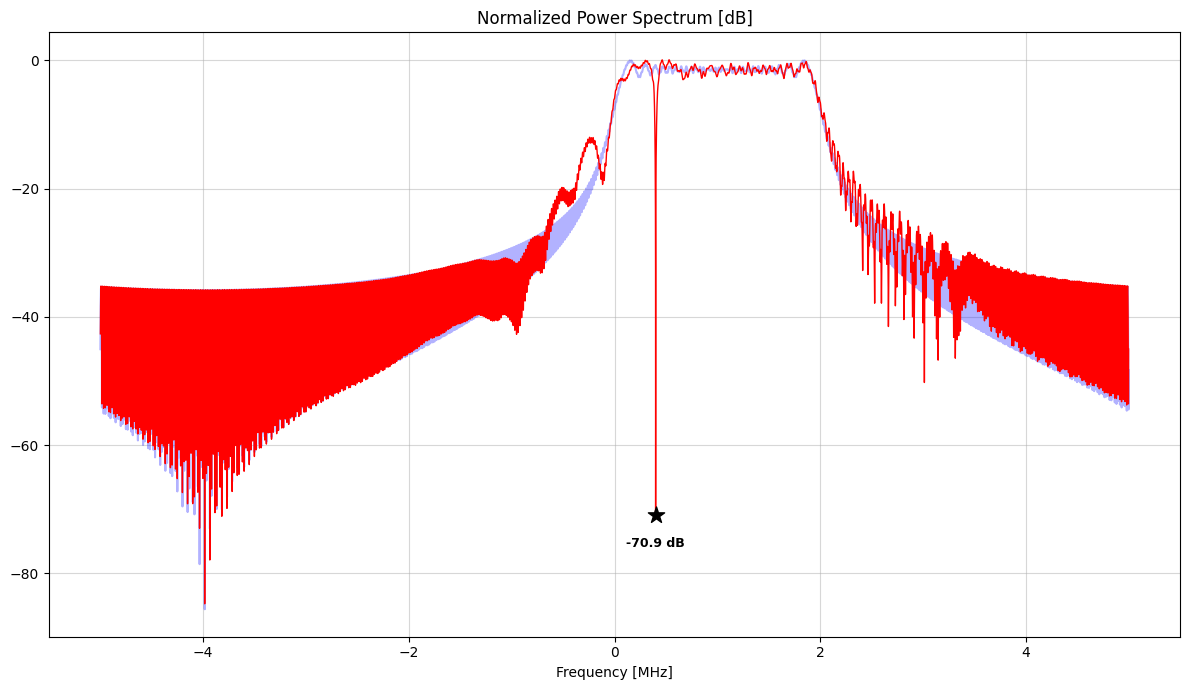

In [16]:
#3 Showing the Null
null_freqs_np = np.array(null_freqs) 


with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
    s_transmit_best = s_base * correction_phasor
    
    phi_learned = best_phi.detach().cpu().numpy()
    s_final_np = s_transmit_best.detach().cpu().numpy()


freqs = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/Fs))


S_orig = np.fft.fftshift(np.fft.fft(s_base.numpy(), n=N_fft))
S_final = np.fft.fftshift(np.fft.fft(s_final_np, n=N_fft))


S_orig_db = 20*np.log10(np.abs(S_orig) + 1e-15)
S_final_db = 20*np.log10(np.abs(S_final) + 1e-15)


peak_ref = np.max(S_orig_db)
S_orig_norm = S_orig_db - peak_ref
S_final_norm = S_final_db - peak_ref


with torch.no_grad():
    # חישוב ב-PyTorch
    exact_vals = torch.matmul(steering_matrix, s_transmit_best)
    energies_torch = torch.abs(exact_vals)**2
    
    # המרה מסודרת ל-Numpy
    energies_np = energies_torch.detach().cpu().numpy()
    
    # חישוב dB ב-Numpy
    exact_db_absolute = 10 * np.log10(energies_np + 1e-40)
    
    # נרמול
    exact_db_relative = exact_db_absolute - peak_ref

print("--- True Null Depths (Calculated Mathematically) ---")
for k, f_val in enumerate(null_freqs_np):
    print(f"Freq {f_val/1e6} MHz: {exact_db_relative[k]:.2f} dB")


# 5. הציור
plt.figure(figsize=(12, 7))

# גרף האות המקורי
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue', alpha=0.3) # original signal

# גרף האות האופטימלי (FFT)
plt.plot(freqs/1e6, S_final_norm, label='Optimized Signal', color='red', linewidth=1) # optimized signal

# stars for exact null depths
plt.scatter(null_freqs_np/1e6, exact_db_relative, 
            color='black', marker='*', s=150, zorder=10, 
            label='Exact Analytical Depth')

# adding text next to stars
for k, f_val in enumerate(null_freqs_np):
    depth = exact_db_relative[k]
    plt.text(f_val/1e6, depth - 5, f"{depth:.1f} dB", 
             color='black', fontweight='bold', ha='center', fontsize=9)

plt.title("Normalized Power Spectrum [dB]")
plt.xlabel("Frequency [MHz]")

#plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)
#plt.xlim(0, B/1e6 + 0.2)
#plt.ylim(-150, 5)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4408\3418961543.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_base = torch.tensor(s_base).detach().clone()
C:\Users\User\AppData\Local\Temp\ipykernel_4408\3418961543.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s_lin = torch.tensor(s_lin).detach().clone()


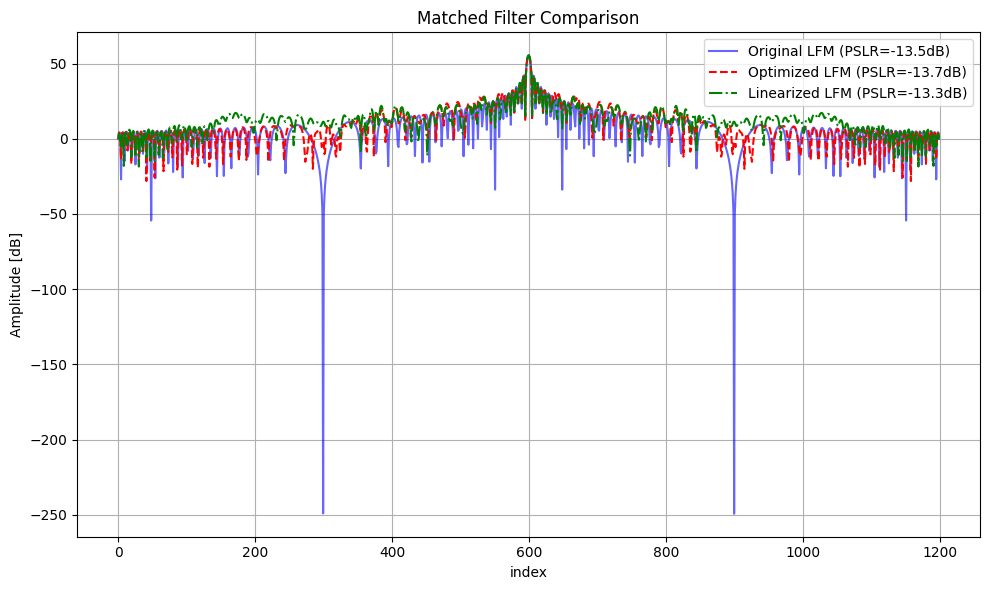

--- PSLR Performence ---
Selected Model based on Minimum Total Loss
Original LFM PSLR:  -13.46 dB
Optimized LFM PSLR: -13.68 dB
Linearized LFM PSLR: -13.32 dB
Degradation:        0.36 dB
Notice, PSLR should be as low as possible, so negative degradation means worse performance.

--- ISLR Performance ---
Original LFM ISLR:  -9.83 dB
Optimized LFM ISLR: -9.35 dB
Linearized LFM ISLR: -9.33 dB
Degradation:        0.02 dB
Notice, ISLR should be as small as possible, so negative degradation means worse performance.



In [17]:
#4 - Matched Filter and PSLR Calculation
with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_best = s_base * correction_phasor

    s_best_np = s_best.detach().numpy()
    s_base_np = s_base.numpy()

    s_base = torch.tensor(s_base).detach().clone()
    s_lin = torch.tensor(s_lin).detach().clone()

mf_orig_db, pslr_orig, islr_orig = calculate_mf_pslr_islr_torch(s_base,True)
mf_new_db, pslr_new, islr_new = calculate_mf_pslr_islr_torch(s_best,True)
mf_lin_db, pslr_lin, islr_lin = calculate_mf_pslr_islr_torch(s_lin,True)

plt.figure(figsize=(10, 6))
plt.plot(mf_orig_db, label=f'Original LFM (PSLR={pslr_orig:.1f}dB)', color='blue', alpha=0.6)
plt.plot(mf_new_db, label=f'Optimized LFM (PSLR={pslr_new:.1f}dB)', color='red', linestyle='--')
plt.plot(mf_lin_db, label=f'Linearized LFM (PSLR={pslr_lin:.1f}dB)', color='green', linestyle='-.')
plt.title("Matched Filter Comparison")
plt.xlabel("index")
plt.ylabel("Amplitude [dB]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"--- PSLR Performence ---")
print(f"Selected Model based on Minimum Total Loss")
print(f"Original LFM PSLR:  {pslr_orig:.2f} dB")
print(f"Optimized LFM PSLR: {pslr_new:.2f} dB")
print(f"Linearized LFM PSLR: {pslr_lin:.2f} dB")
print(f"Degradation:        {pslr_lin - pslr_new:.2f} dB")
print("Notice, PSLR should be as low as possible, so negative degradation means worse performance.\n")


print(f"--- ISLR Performance ---")
print(f"Original LFM ISLR:  {islr_orig:.2f} dB")
print(f"Optimized LFM ISLR: {islr_new:.2f} dB")
print(f"Linearized LFM ISLR: {islr_lin:.2f} dB")
print(f"Degradation:        {islr_lin - islr_new:.2f} dB")
print("Notice, ISLR should be as small as possible, so negative degradation means worse performance.\n")

# lags = np.arange(-len(s_base_np) + 1, len(s_base_np))
# time_lags = (lags / Fs) * 1e6 



In [ ]:
#5 Saving phi
phi_numpy = best_phi.detach().cpu().numpy()


correction_phasor = np.exp(1j * phi_numpy)


filename = 'optimal_phasor.npy'
np.save(filename, correction_phasor)

print(f"Success! Saved optimized phasor to '{filename}'")
print(f"File shape: {correction_phasor.shape}")

Success! Saved optimized phasor to 'optimal_phasor_width1e4.npy'
File shape: (600,)


In [ ]:
import optuna
import torch

def objective(trial):
    
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    beta_smooth = trial.suggest_float("beta_smooth", 1e-3, 1e+3, log=True)
    beta_norm = trial.suggest_float("beta_norm", 1e-3, 1e+3, log=True)
    beta_pslr = trial.suggest_float("beta_pslr", 1e-3, 1e+3, log=True)
    beta_islr = trial.suggest_float("beta_islr", 1e-3, 1e+3, log=True)
    beta_div1 = trial.suggest_float("beta_div1", 1e-3, 1e+3, log=True)
    beta_div2 = trial.suggest_float("beta_div2", 1e-3, 1e+3, log=True) 

    phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    
    for i in range(5000): 
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        
       
        loss_nulls = torch.sum(energies) 
        
        diff_phi = phi[1:] - phi[:-1]
        reg_term = beta_smooth * torch.sum(diff_phi**2)
        loss_norm = beta_norm * torch.sum(phi**2)
        
        
        if beta_div1 > 0 or beta_div2 > 0:
            integrals1 = [
                torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])

            integrals2 = [
                torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
        else:
            loss_div1 = 0
            loss_div2 = 0
        
        
        mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit,False)
        loss_pslr = beta_pslr * pslr
        loss_islr = beta_islr * islr 

        
        loss = loss_norm + loss_div1 + loss_div2 + loss_nulls + loss_pslr + loss_islr + reg_term
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    
    
    final_null_energy = loss_nulls.item()
    final_pslr_val = pslr.item()
    final_islr_val = islr.item()

    return final_null_energy, final_pslr_val, final_islr_val


study = optuna.create_study(directions=["minimize", "minimize", "minimize"])
study.optimize(objective, n_trials=50)



[I 2026-02-27 12:09:13,655] A new study created in memory with name: no-name-4f5dc010-b5bd-416f-a2eb-900ef88729d2
C:\Users\User\AppData\Local\Temp\ipykernel_4408\2004855673.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
[I 2026-02-27 12:09:34,559] Trial 0 finished with values: [88.37556321703742, 0.04573200017959841, 0.11191834496450308] and parameters: {'lr': 0.011723807179568644, 'beta_smooth': 0.0625388210088191, 'beta_norm': 53.95810723276555, 'beta_pslr': 273.8050336921955, 'beta_islr': 342.6779492205896, 'beta_div1': 27.30237948473838, 'beta_div2': 0.050577931838282505}.
[I 2026-02-27 12:09:55,330] Trial 1 finished with values: [888.3027181613613, 0.04522025163235566, 0.1068519887284887] and parameters: {'lr': 0.001438147559038407, 'beta_smooth': 0.059814

In [27]:
import optuna.visualization as vis

fig = vis.plot_pareto_front(
    study, 
    target_names=["Null Energy (Min)", "PSLR ", "ISLR (Min)"]
)
#fig.show()
import numpy as np

# 1. יצירת הגרף המקורי של אופטונה (הכותרות כבר עם [dB])
fig1 = vis.plot_pareto_front(
    study, 
    target_names=["Null Energy [dB]", "PSLR [dB]", "ISLR [dB]"],
    include_dominated_trials=False
)

# 2. המרת כל הנתונים של שלושת הצירים ל-dB
for trace in fig1.data:
    # ציר X: אנרגיית החורים (Nulls)
    if trace.x is not None:
        trace.x = 10 * np.log10(np.array(trace.x, dtype=float) + 1e-20)
        
    # ציר Y: המדד השני (PSLR)
    if trace.y is not None:
        trace.y = 10 * np.log10(np.array(trace.y, dtype=float) + 1e-20)
        
    # ציר Z: המדד השלישי (ISLR)
    if trace.z is not None:
        trace.z = 10 * np.log10(np.array(trace.z, dtype=float) + 1e-20)

# 3. עדכון התצוגה התלת-מימדית כדי שהצירים יהיו ברורים
fig1.update_layout(
    scene=dict(
        xaxis_title="Null Energy [dB]",
        yaxis_title="PSLR [dB]",
        zaxis_title="ISLR [dB]"
    )
)

# 4. הצגת הגרף
fig1.show()
fig2 = vis.plot_pareto_front(
    study,
    targets=lambda t: (t.values[0], t.values[1]), # חיתוך ל-2D
    target_names=["Null Energy (Min)", "PSLR (Max)"],
    include_dominated_trials=False
    
)
#fig2.show()
fig3 = vis.plot_parallel_coordinate(
    study,
    target=lambda t: t.values[1], # מסתכלים על ה-PSLR
    target_name="PSLR (dB)"
)
#fig3.show()
fig4 = vis.plot_param_importances(
    study,
    target=lambda t: t.values[0], # מסתכלים על ה-Nulls
    target_name="Null Energy"
)
#fig4.show()

print("\n--- Best Options on the Pareto Front ---")
best_trials = study.best_trials

import numpy as np

print("\n--- Best Options on the Pareto Front ---")
best_trials = study.best_trials

for i, trial in enumerate(best_trials):
    # שליפת הערכים הליניאריים שחזרו מאופטונה
    null_lin = trial.values[0]
    pslr_lin = trial.values[1]
    islr_lin = trial.values[2]
    
    # המרה ל-dB (נוסיף 1e-20 כדי למנוע שגיאת log של אפס)
    null_db = 10 * np.log10(null_lin + 1e-20)
    pslr_db = 10 * np.log10(pslr_lin + 1e-20)
    islr_db = 10 * np.log10(islr_lin + 1e-20)
    
    print(f"\nOption {i+1} (Trial #{trial.number}):")
    # הדפסה יפה שמציגה את המעבר מליניארי ל-dB
    print(f"  Null Energy: {null_lin:.2e}  -->  {null_db:.2f} dB")
    print(f"  PSLR:        {pslr_lin:.6f}  -->  {pslr_db:.2f} dB")
    print(f"  ISLR:        {islr_lin:.6f}  -->  {islr_db:.2f} dB")
    
    print("  Betas to use:")
    for key, value in trial.params.items():
        print(f"    {key} = {value:.6e}")


--- Best Options on the Pareto Front ---

--- Best Options on the Pareto Front ---

Option 1 (Trial #12):
  Null Energy: 1.51e-06  -->  -58.21 dB
  PSLR:        0.037775  -->  -14.23 dB
  ISLR:        0.077773  -->  -11.09 dB
  Betas to use:
    lr = 3.591796e-04
    beta_smooth = 2.883555e-03
    beta_norm = 1.590088e-03
    beta_pslr = 4.936905e+00
    beta_islr = 5.785497e+00
    beta_div1 = 1.068091e-01
    beta_div2 = 2.675273e-01

Option 2 (Trial #35):
  Null Energy: 2.36e-04  -->  -36.27 dB
  PSLR:        0.002220  -->  -26.54 dB
  ISLR:        0.011282  -->  -19.48 dB
  Betas to use:
    lr = 7.154870e-04
    beta_smooth = 3.101150e-03
    beta_norm = 2.999125e-03
    beta_pslr = 8.179416e-03
    beta_islr = 5.777466e+02
    beta_div1 = 1.886112e+02
    beta_div2 = 5.222674e+00

Option 3 (Trial #36):
  Null Energy: 1.54e-03  -->  -28.13 dB
  PSLR:        0.001228  -->  -29.11 dB
  ISLR:        0.124723  -->  -9.04 dB
  Betas to use:
    lr = 9.929495e-03
    beta_smooth = 1.88

In [ ]:
pip install plotly
pip install --upgrade nbformat

In [57]:
# calculating basic anchor for beta val's 

import copy 

phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

learning_rate =  1
iterations = 1 
beta_smooth = 1
beta_norm = 1 # 1.0914710219012044e-05
beta_div1 = 1
beta_div2 = 1
beta_pslr = 1
beta_islr = 1

optimizer = torch.optim.Adam([phi], lr=learning_rate)





    
correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
s_transmit = s_base * correction_phasor


spectral_vals = torch.matmul(steering_matrix, s_transmit)
energies = torch.abs(spectral_vals)**2

    
loss_nulls = torch.sum(energies) 

diff_phi = phi[1:] - phi[:-1]
reg_term = beta_smooth * torch.sum(diff_phi**2)


loss_norm = beta_norm * torch.sum(phi**2)

if beta_div1 > 0 or beta_div2 > 0:
    integrals1 = [
        (1/((60*10**-6)**2))*torch.trapezoid(z[:, k] * correction_phasor * t, x=t) 
        for k in range(z.shape[1])
    ]
    
    loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])


    integrals2 = [
        (1/((60*10**-6)**3))*torch.trapezoid(z[:, k] * correction_phasor * (t**2), x=t) 
        for k in range(z.shape[1])
    ]
    loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
else:
    loss_div1 = 0
    loss_div2 = 0

mf_db, pslr, islr = calculate_mf_pslr_islr_torch(s_transmit, False)

loss_pslr = beta_pslr * pslr
loss_islr = beta_islr * islr 

print(f'norm_norm =1/{loss_norm}')
print(f'norm_div1 =1/{loss_div1}')
print(f'norm_div2 =1/{loss_div2}')
print(f'norm_nulls =1/{loss_nulls}')
print(f'norm_pslr =1/{loss_pslr}')
print(f'norm_islr =1/{-loss_islr}')
print(f'norm_smooth =1/{reg_term}')
loss = loss_norm  + loss_div1 + loss_div2  + loss_nulls+ loss_pslr + loss_islr + reg_term


norm_norm =1/12.377391138907695
norm_div1 =1/0.000978264127076254
norm_div2 =1/0.000861558612898089
norm_nulls =1/0.46179487055553126
norm_pslr =1/0.2158172617376692
norm_islr =1/-0.11674486206525744
norm_smooth =1/3.3783233686063587


C:\Users\Elad\AppData\Local\Temp\ipykernel_26492\3149512200.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)
